# Why This Notebook Exists

In this notebook, we build a bot detector from mouse movement data.

Each sample is a sequence of points:

\[
(t, x, y)
\]

where:

- `t` is the timestamp
- `x` is the horizontal mouse position
- `y` is the vertical mouse position

The goal is to classify each session as either:

- **Human**
- **Bot**

At first, this looks like a classic time-series problem. A common first idea would be to use an LSTM, GRU, or Transformer because the data is sequential.

However, that is not the best choice here.

---

## The Real Problem: Small Data

We only have around **2,000 labeled samples**.

That is a small dataset for deep learning.

Sequence models such as LSTMs and Transformers usually have many parameters. With only 2,000 examples, they can easily overfit.

Instead of learning real behavior, the model may memorize random patterns in the training data.

For example, it might learn noise such as:

> “sessions with this exact timestamp pattern are bots”

instead of learning useful behavior such as:

> “bots often move in unnaturally straight or perfectly smooth paths”

So the main challenge is not just the model.

The main challenge is **data scarcity**.

---

## Why Not Use a Sequence Model?

A raw sequence model treats the mouse path as a list of numbers.

That means the model has to learn many things from scratch:

- that `x` and `y` represent 2D space
- that nearby coordinates are close on the screen
- that straight lines, curves, jitter, pauses, and overshooting matter
- that human movement has natural noise
- that bot movement is often too smooth or too mathematical

With a small dataset, forcing the model to learn all of this from scratch is risky.

A powerful model with too little data usually memorizes instead of generalizing.

---

## The Key Idea: Change the Representation

Instead of treating mouse movement only as a time-series, we convert it into an image.

We render each mouse trajectory on a 2D canvas:

1. Plot the `(x, y)` coordinates.
2. Connect the points to form a path.
3. Optionally encode time or speed using color, brightness, or line thickness.

Now the problem becomes an image classification task.

This is useful because mouse movement is naturally geometric.

Humans and bots often differ in the **shape** of their movement:

- humans produce small corrections, hesitation, jitter, and overshoot
- bots often produce straight lines, perfect curves, or repeated patterns

These differences are easier to see in a 2D image than in a raw list of numbers.

---

## Why This Approach Is Better

By converting trajectories into images, we can use a pre-trained computer vision model such as ResNet or MobileNet.

This gives us a major advantage: **transfer learning**.

A CNN pre-trained on a large image dataset already knows how to detect useful visual patterns such as:

- edges
- curves
- corners
- textures
- straight lines
- noisy shapes

We do not need to train the whole model from scratch.

Instead, we can freeze most of the pre-trained model and only train a small final classifier for our task.

This reduces the number of trainable parameters and makes the model much more suitable for a small dataset.

---

## What We Are Doing in This Notebook

In this notebook, we will:

1. Load mouse movement samples.
2. Convert each trajectory into a 2D image.
3. Use a pre-trained CNN as a feature extractor.
4. Train a small classification head to predict `Human` or `Bot`.
5. Evaluate whether this representation improves generalization.

The goal is not to use the most complex model.

The goal is to choose the model and representation that match the data we actually have.

---

## Main Lesson

This problem looks like a time-series problem, but the dataset size changes the best solution.

With limited labeled data, representation matters more than model complexity.

Instead of training a large sequence model from scratch, we use a smarter representation that allows us to reuse strong pre-trained visual features.

In small-data machine learning:

> Do not choose the model only because of the data type.  
> Choose the representation that gives the model the strongest prior.

In [1]:
# Generate human/bot Samples, the whole code here is just to create some samples to work with instead of the real data
from dataclasses import dataclass
from typing import List, Tuple
import random

random.seed(42)

@dataclass
class MouseSample:
    sample_id: str
    label: str
    points: List[Tuple[float, float, float]]

def generate_human_trajectory(n_points=40):
    points = []
    x = random.uniform(100, 300)
    y = random.uniform(100, 300)
    t = 0.0

    for _ in range(n_points):
        dx = random.uniform(-12, 12)
        dy = random.uniform(-12, 12)

        x += dx + random.uniform(-2, 2)
        y += dy + random.uniform(-2, 2)
        t += random.uniform(0.01, 0.05)

        points.append((x, y, t))

    return points

def generate_bot_trajectory(n_points=40):
    points = []
    x1 = random.uniform(50, 100)
    y1 = random.uniform(50, 100)
    x2 = random.uniform(350, 450)
    y2 = random.uniform(350, 450)

    for i in range(n_points):
        alpha = i / max(1, n_points - 1)
        x = x1 * (1 - alpha) + x2 * alpha
        y = y1 * (1 - alpha) + y2 * alpha
        t = i * 0.02
        points.append((x, y, t))

    return points

def build_demo_samples(n_human=5, n_bot=5):
    samples = []

    for i in range(n_human):
        samples.append(
            MouseSample(
                sample_id=f"human_{i:03d}",
                label="human",
                points=generate_human_trajectory()
            )
        )

    for i in range(n_bot):
        samples.append(
            MouseSample(
                sample_id=f"bot_{i:03d}",
                label="bot",
                points=generate_bot_trajectory()
            )
        )

    random.shuffle(samples)
    return samples

samples = build_demo_samples(n_human=5, n_bot=5)

print("Total samples:", len(samples))
print()
print("First sample:")
print("id    :", samples[0].sample_id)
print("label :", samples[0].label)
print("points:", samples[0].points[:5])

Total samples: 10

First sample:
id    : bot_003
label : bot
points: [(93.48477133847723, 66.42797767161153, 0.0), (100.44042894503279, 76.00810910472856, 0.02), (107.39608655158837, 85.58824053784559, 0.04), (114.35174415814394, 95.16837197096262, 0.06), (121.3074017646995, 104.74850340407966, 0.08)]


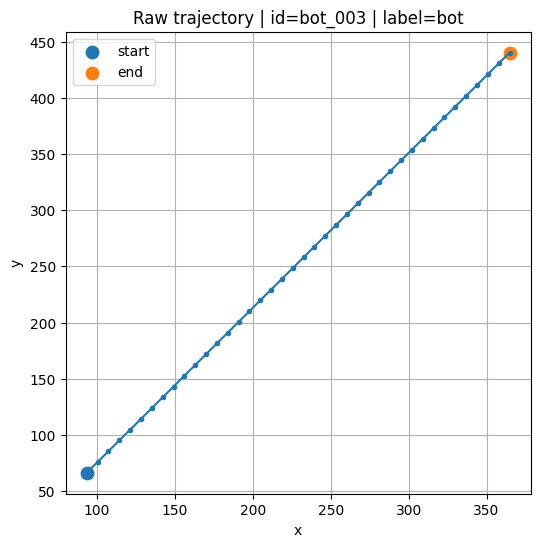

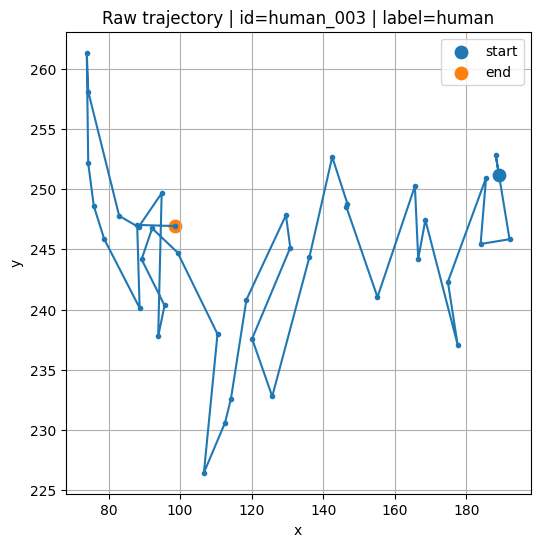

In [2]:
# ploting the point to similate the movement
import matplotlib.pyplot as plt
import numpy as np

def plot_sample(sample):
    pts = np.array(sample.points)

    x = pts[:, 0]
    y = pts[:, 1]
    t = pts[:, 2]

    plt.figure(figsize=(6, 6))
    plt.plot(x, y, marker='o', markersize=3, linewidth=1.5)
    plt.scatter(x[0], y[0], s=80, label="start")
    plt.scatter(x[-1], y[-1], s=80, label="end")

    plt.title(f"Raw trajectory | id={sample.sample_id} | label={sample.label}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

# show 2 examples
plot_sample(samples[0])
plot_sample(samples[1])

In [3]:
# Ohh here starting to similate the real movement, adding the speed of the movement as a color
import numpy as np
import matplotlib.pyplot as plt
import cv2

def normalize_points_to_canvas(points, width=224, height=224, padding=10, flip_y=True):
    pts = np.array(points, dtype=np.float32)

    xs = pts[:, 0]
    ys = pts[:, 1]

    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()

    range_x = max(max_x - min_x, 1e-6)
    range_y = max(max_y - min_y, 1e-6)

    scale_x = (width - 2 * padding) / range_x
    scale_y = (height - 2 * padding) / range_y
    scale = min(scale_x, scale_y)

    normalized = []
    for x, y, t in points:
        nx = (x - min_x) * scale + padding

        if flip_y:
            ny = height - padding - (y - min_y) * scale
        else:
            ny = (y - min_y) * scale + padding

        normalized.append((nx, ny, t))

    return normalized


def euclidean_distance(p1, p2):
    x1, y1, _ = p1
    x2, y2, _ = p2
    return ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5


def compute_speeds(points):
    speeds = []
    for i in range(1, len(points)):
        p1 = points[i - 1]
        p2 = points[i]
        d = euclidean_distance(p1, p2)
        dt = max(p2[2] - p1[2], 1e-6)
        speeds.append(d / dt)
    return speeds


def speed_to_color(speed, min_speed, max_speed):
    if max_speed - min_speed < 1e-6:
        ratio = 0.5
    else:
        ratio = (speed - min_speed) / (max_speed - min_speed)

    blue = int(255 * (1 - ratio))
    red = int(255 * ratio)
    green = 50
    return (blue, green, red)   # BGR for OpenCV


def render_trajectory_image(points, width=224, height=224, padding=10, thickness=2, flip_y=True, use_speed_color=True):
    canvas = np.zeros((height, width, 3), dtype=np.uint8)

    if len(points) < 2:
        return canvas

    normalized_points = normalize_points_to_canvas(
        points,
        width=width,
        height=height,
        padding=padding,
        flip_y=flip_y
    )

    speeds = compute_speeds(normalized_points)
    min_speed = min(speeds) if speeds else 0.0
    max_speed = max(speeds) if speeds else 1.0

    for i in range(1, len(normalized_points)):
        x1, y1, _ = normalized_points[i - 1]
        x2, y2, _ = normalized_points[i]

        p1 = (int(round(x1)), int(round(y1)))
        p2 = (int(round(x2)), int(round(y2)))

        if use_speed_color:
            color = speed_to_color(speeds[i - 1], min_speed, max_speed)
        else:
            color = (255, 255, 255)

        cv2.line(canvas, p1, p2, color, thickness)

    return canvas

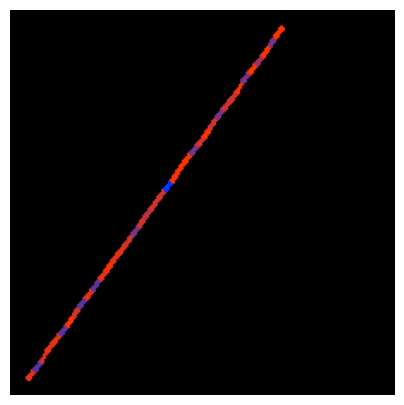

In [4]:
sample = samples[0]
img = render_trajectory_image(sample.points, flip_y=True, use_speed_color=True)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [5]:
# No worries, just saving our mock data
import os
import shutil
import cv2

ROOT_DIR = "root"

def reset_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

def save_dataset_split(samples, root_dir="root"):
    # recreate folders
    reset_dir(root_dir)

    train_human_dir = os.path.join(root_dir, "train", "human")
    train_bot_dir   = os.path.join(root_dir, "train", "bot")
    test_human_dir  = os.path.join(root_dir, "test", "human")
    test_bot_dir    = os.path.join(root_dir, "test", "bot")

    os.makedirs(train_human_dir, exist_ok=True)
    os.makedirs(train_bot_dir, exist_ok=True)
    os.makedirs(test_human_dir, exist_ok=True)
    os.makedirs(test_bot_dir, exist_ok=True)

    # separate by label
    human_samples = [s for s in samples if s.label == "human"]
    bot_samples   = [s for s in samples if s.label == "bot"]

    # safety check
    if len(human_samples) < 5:
        raise ValueError("Need at least 5 human samples")
    if len(bot_samples) < 5:
        raise ValueError("Need at least 5 bot samples")

    # split: 4 train + 1 test
    train_humans = human_samples[:4]
    test_humans  = human_samples[4:5]

    train_bots = bot_samples[:4]
    test_bots  = bot_samples[4:5]

    # helper to save one list
    def save_group(group, folder):
        for sample in group:
            img = render_trajectory_image(
                sample.points,
                flip_y=True,
                use_speed_color=True
            )
            out_path = os.path.join(folder, f"{sample.sample_id}.png")
            cv2.imwrite(out_path, img)
            print(f"Saved: {out_path}")

    save_group(train_humans, train_human_dir)
    save_group(train_bots, train_bot_dir)
    save_group(test_humans, test_human_dir)
    save_group(test_bots, test_bot_dir)

    print("\nDone.")
    print("Train human:", len(os.listdir(train_human_dir)))
    print("Train bot  :", len(os.listdir(train_bot_dir)))
    print("Test human :", len(os.listdir(test_human_dir)))
    print("Test bot   :", len(os.listdir(test_bot_dir)))

save_dataset_split(samples, ROOT_DIR)

Saved: root/train/human/human_003.png
Saved: root/train/human/human_000.png
Saved: root/train/human/human_001.png
Saved: root/train/human/human_002.png
Saved: root/train/bot/bot_003.png
Saved: root/train/bot/bot_004.png
Saved: root/train/bot/bot_001.png
Saved: root/train/bot/bot_002.png
Saved: root/test/human/human_004.png
Saved: root/test/bot/bot_000.png

Done.
Train human: 4
Train bot  : 4
Test human : 1
Test bot   : 1


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names
from torch.utils.data import DataLoader

In [7]:
# We are gonna work with ResNet for our classification
#Inspect available node names
weights = ResNet18_Weights.DEFAULT
base = resnet18(weights=weights)

train_nodes, eval_nodes = get_graph_node_names(base)
print(eval_nodes)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


['x', 'conv1', 'bn1', 'relu', 'maxpool', 'layer1.0.conv1', 'layer1.0.bn1', 'layer1.0.relu', 'layer1.0.conv2', 'layer1.0.bn2', 'layer1.0.add', 'layer1.0.relu_1', 'layer1.1.conv1', 'layer1.1.bn1', 'layer1.1.relu', 'layer1.1.conv2', 'layer1.1.bn2', 'layer1.1.add', 'layer1.1.relu_1', 'layer2.0.conv1', 'layer2.0.bn1', 'layer2.0.relu', 'layer2.0.conv2', 'layer2.0.bn2', 'layer2.0.downsample.0', 'layer2.0.downsample.1', 'layer2.0.add', 'layer2.0.relu_1', 'layer2.1.conv1', 'layer2.1.bn1', 'layer2.1.relu', 'layer2.1.conv2', 'layer2.1.bn2', 'layer2.1.add', 'layer2.1.relu_1', 'layer3.0.conv1', 'layer3.0.bn1', 'layer3.0.relu', 'layer3.0.conv2', 'layer3.0.bn2', 'layer3.0.downsample.0', 'layer3.0.downsample.1', 'layer3.0.add', 'layer3.0.relu_1', 'layer3.1.conv1', 'layer3.1.bn1', 'layer3.1.relu', 'layer3.1.conv2', 'layer3.1.bn2', 'layer3.1.add', 'layer3.1.relu_1', 'layer4.0.conv1', 'layer4.0.bn1', 'layer4.0.relu', 'layer4.0.conv2', 'layer4.0.bn2', 'layer4.0.downsample.0', 'layer4.0.downsample.1', 'lay

In [8]:
# The class
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        weights = ResNet18_Weights.DEFAULT
        base = resnet18(weights=weights)
        in_features = base.fc.in_features

        self.backbone = create_feature_extractor(
            base,
            return_nodes={"layer4": "features"}
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Linear(in_features, 1)

    def forward(self, x):
        feat = self.backbone(x)["features"]
        feat = self.pool(feat)
        feat = torch.flatten(feat, 1)
        out = self.head(feat)
        return out


weights = ResNet18_Weights.DEFAULT
train_transform = weights.transforms()

In [9]:
train_dataset = ImageFolder(
    root="root/train",
    transform=train_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=1,
    pin_memory=torch.cuda.is_available()
)

print(train_dataset.class_to_idx)

{'bot': 0, 'human': 1}


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyModel().to(device)

for param in model.backbone.parameters():
    param.requires_grad = False

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.head.parameters(), lr=1e-3, momentum=0.9)

In [11]:
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    model.backbone.eval()

    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {epoch_loss:.4f}")

Epoch 1/15 - Loss: 0.5689
Epoch 2/15 - Loss: 0.1611
Epoch 3/15 - Loss: 0.0468
Epoch 4/15 - Loss: 0.0219
Epoch 5/15 - Loss: 0.0149
Epoch 6/15 - Loss: 0.0120
Epoch 7/15 - Loss: 0.0103
Epoch 8/15 - Loss: 0.0095
Epoch 9/15 - Loss: 0.0087
Epoch 10/15 - Loss: 0.0082
Epoch 11/15 - Loss: 0.0077
Epoch 12/15 - Loss: 0.0074
Epoch 13/15 - Loss: 0.0070
Epoch 14/15 - Loss: 0.0067
Epoch 15/15 - Loss: 0.0064


In [12]:
# build test dataset from root/test
test_dataset = ImageFolder(
    root="root/test",
    transform=train_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available()
)

# switch model to evaluation mode
model.eval()

correct = 0
total = 0

idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}

all_results = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

        outputs = model(inputs)                  # raw logits [B, 1]
        probs = torch.sigmoid(outputs)           # probabilities [B, 1]
        preds = (probs >= 0.5).float()           # predicted labels [B, 1]

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        for i in range(labels.size(0)):
            true_idx = int(labels[i].item())
            pred_idx = int(preds[i].item())
            prob = float(probs[i].item())

            all_results.append({
                "true_idx": true_idx,
                "true_label": idx_to_class[true_idx],
                "pred_idx": pred_idx,
                "pred_label": idx_to_class[pred_idx],
                "probability_of_class_1": prob
            })

accuracy = correct / total if total > 0 else 0.0
print(f"Test Accuracy: {accuracy:.4f}")

print("\nDetailed predictions:")
for r in all_results:
    print(r)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Test Accuracy: 1.0000

Detailed predictions:
{'true_idx': 0, 'true_label': 'bot', 'pred_idx': 0, 'pred_label': 'bot', 'probability_of_class_1': 0.0035198256373405457}
{'true_idx': 1, 'true_label': 'human', 'pred_idx': 1, 'pred_label': 'human', 'probability_of_class_1': 0.9983514547348022}
